In [12]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, average_precision_score,
                             precision_recall_curve)
import matplotlib.pyplot as plt

torch.manual_seed(42)
np.random.seed(42)

## Dataset

[Credit Card Fraud Detection](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud/data) — 284,807 transactions, 492 frauds (0.17%).  
Features V1-V28 are already PCA components; only `Time` and `Amount` are in their original scale.

In [13]:
df = pd.read_csv('creditcard.csv')
print(df.shape)
print(df['Class'].value_counts())
print(f'\nFrauds: {df["Class"].sum()} ({df["Class"].mean()*100:.3f}%)')

(284807, 31)
Class
0    284315
1       492
Name: count, dtype: int64

Frauds: 492 (0.173%)


## Preprocessing

`Amount` and `Time` are standardized to match the scale of the PCA features.  
**Three-way stratified split:**
- **Train (68%)** — normal transactions only, used to train the autoencoder
- **Validation (12%)** — all classes, used to calibrate the weighted anomaly score (no data leakage on test)
- **Test (20%)** — final evaluation only

In [14]:
scaler = StandardScaler()
df['Amount'] = scaler.fit_transform(df[['Amount']])
df['Time']   = scaler.fit_transform(df[['Time']])

X = df.drop('Class', axis=1).values
y = df['Class'].values
feature_names = ['Time'] + [f'V{i}' for i in range(1, 29)] + ['Amount']

X_tv, X_test, y_tv, y_test = train_test_split(X, y, test_size=0.20, stratify=y, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_tv, y_tv, test_size=0.15, stratify=y_tv, random_state=42)
X_train_normal = X_train[y_train == 0]

print(f'Train (normal only): {X_train_normal.shape}')
print(f'Validation:          {X_val.shape}  | frauds: {y_val.sum()}')
print(f'Test:                {X_test.shape} | frauds: {y_test.sum()}')

Train (normal only): (193333, 30)
Validation:          (34177, 30)  | frauds: 59
Test:                (56962, 30) | frauds: 98


## Autoencoder Architecture

Symmetric encoder-decoder with a 5-dimensional bottleneck.

```
Input (30) -> 20 -> 10 -> 5  [bottleneck]  -> 10 -> 20 -> Output (30)
```

No Dropout or BatchNorm: the model must learn to reconstruct normal transactions as precisely as possible.
Any regularization adds noise to reconstructions and weakens the anomaly signal.

**Core idea:** train only on normal transactions. At inference time, fraudulent transactions — never seen during training — will have a higher reconstruction error, which serves as the anomaly score.

In [15]:
class Autoencoder(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 20), nn.ReLU(),
            nn.Linear(20, 10),        nn.ReLU(),
            nn.Linear(10, 5),         nn.ReLU(),
        )
        self.decoder = nn.Sequential(
            nn.Linear(5, 10),         nn.ReLU(),
            nn.Linear(10, 20),        nn.ReLU(),
            nn.Linear(20, input_dim),
        )

    def forward(self, x):
        return self.decoder(self.encoder(x))

input_dim = X_train_normal.shape[1]
model = Autoencoder(input_dim)
print(model)
print(f'\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}')

Autoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=30, out_features=20, bias=True)
    (1): ReLU()
    (2): Linear(in_features=20, out_features=10, bias=True)
    (3): ReLU()
    (4): Linear(in_features=10, out_features=5, bias=True)
    (5): ReLU()
  )
  (decoder): Sequential(
    (0): Linear(in_features=5, out_features=10, bias=True)
    (1): ReLU()
    (2): Linear(in_features=10, out_features=20, bias=True)
    (3): ReLU()
    (4): Linear(in_features=20, out_features=30, bias=True)
  )
)

Total parameters: 1,795


## Training

If a pre-trained model is found (`autoencoder.pt`), it is loaded directly — no retraining needed.  
Set `FORCE_RETRAIN = True` to train from scratch.

Epoch  10/100  Loss: 0.361652  LR: 1.00e-03
Epoch  20/100  Loss: 0.334975  LR: 1.00e-03
Epoch  30/100  Loss: 0.324178  LR: 1.00e-03
Epoch  40/100  Loss: 0.318049  LR: 1.00e-03
Epoch  50/100  Loss: 0.311576  LR: 1.00e-03
Epoch  60/100  Loss: 0.308267  LR: 1.00e-03
Epoch  70/100  Loss: 0.305434  LR: 1.00e-03
Epoch  80/100  Loss: 0.285049  LR: 1.00e-03
Epoch  90/100  Loss: 0.280559  LR: 1.00e-03
Epoch 100/100  Loss: 0.278611  LR: 1.00e-03

Model saved to autoencoder.pt


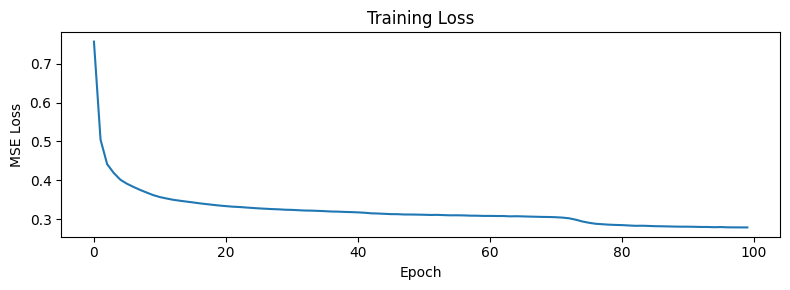

In [16]:
FORCE_RETRAIN = False
MODEL_PATH    = 'autoencoder.pt'

if not FORCE_RETRAIN and os.path.exists(MODEL_PATH):
    model.load_state_dict(torch.load(MODEL_PATH, weights_only=True))
    model.eval()
    print(f'Pre-trained model loaded from {MODEL_PATH}')
else:
    X_train_t = torch.FloatTensor(X_train_normal)
    loader    = DataLoader(TensorDataset(X_train_t), batch_size=256, shuffle=True)

    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)

    nb_epochs    = 100
    train_losses = []

    for epoch in range(1, nb_epochs + 1):
        model.train()
        epoch_loss = 0
        for (batch,) in loader:
            optimizer.zero_grad()
            loss = criterion(model(batch), batch)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item() * batch.size(0)
        avg = epoch_loss / len(X_train_t)
        train_losses.append(avg)
        scheduler.step(avg)
        if epoch % 10 == 0:
            print(f'Epoch {epoch:3d}/{nb_epochs}  Loss: {avg:.6f}  LR: {optimizer.param_groups[0]["lr"]:.2e}')

    torch.save(model.state_dict(), MODEL_PATH)
    print(f'\nModel saved to {MODEL_PATH}')

    plt.figure(figsize=(8, 3))
    plt.plot(train_losses)
    plt.xlabel('Epoch'); plt.ylabel('MSE Loss'); plt.title('Training Loss')
    plt.tight_layout(); plt.show()

## Anomaly Score

### Step 1 — Mean Squared Error (baseline)

The per-sample reconstruction error is the baseline anomaly score.  
We verify the separation between normal and fraudulent transactions on both validation and test sets.

Val  — normal: 0.2911  | fraud: 13.1542
Test — normal: 0.2827 | fraud: 17.9286


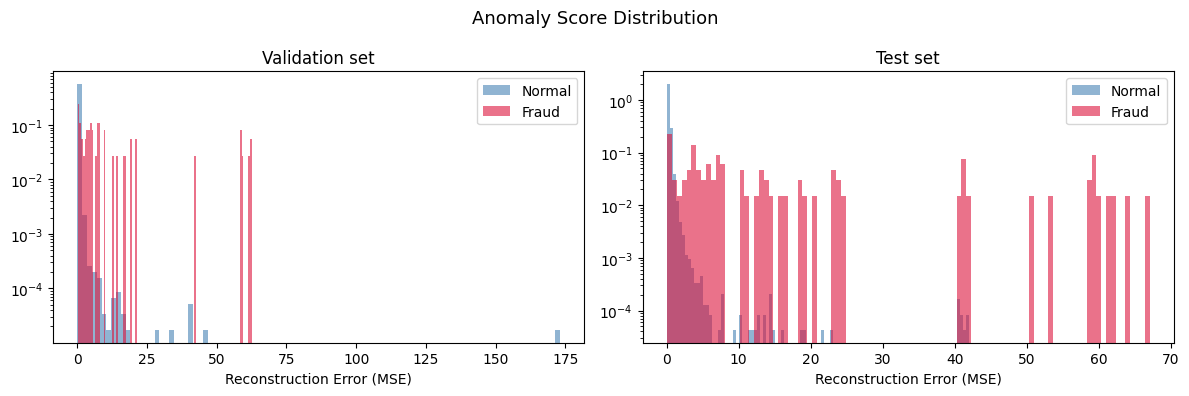

In [17]:
model.eval()
X_val_t  = torch.FloatTensor(X_val)
X_test_t = torch.FloatTensor(X_test)

with torch.no_grad():
    val_rec  = model(X_val_t).numpy()
    test_rec = model(X_test_t).numpy()

err_val  = np.mean((X_val  - val_rec)  ** 2, axis=1)
err_test = np.mean((X_test - test_rec) ** 2, axis=1)

print(f'Val  — normal: {err_val[y_val==0].mean():.4f}  | fraud: {err_val[y_val==1].mean():.4f}')
print(f'Test — normal: {err_test[y_test==0].mean():.4f} | fraud: {err_test[y_test==1].mean():.4f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, err, yy, title in zip(axes,
        [err_val, err_test], [y_val, y_test], ['Validation set', 'Test set']):
    ax.hist(err[yy==0], bins=100, alpha=0.6, label='Normal', color='steelblue', density=True)
    ax.hist(err[yy==1], bins=100, alpha=0.6, label='Fraud',  color='crimson',   density=True)
    ax.set_yscale('log'); ax.set_xlabel('Reconstruction Error (MSE)')
    ax.set_title(title); ax.legend()
plt.suptitle('Anomaly Score Distribution', fontsize=13)
plt.tight_layout(); plt.show()

### Step 2 — Weighted MSE

The plain MSE treats all 30 features equally. However, some features contribute much more to the fraud/normal separation.

Weights are computed on the **validation set** to avoid data leakage on the test set:

    w_i  =  max(0,  MSE_fraud_i  -  MSE_normal_i)

    score(x)  =  sum_i  w_i * (x_i - x_hat_i)^2

Weights and the validation reconstruction are saved to disk so they can be reused without recomputing.

In [18]:
WEIGHTS_PATH = 'weights.npy'

if not FORCE_RETRAIN and os.path.exists(WEIGHTS_PATH):
    weights = np.load(WEIGHTS_PATH)
    print(f'Weights loaded from {WEIGHTS_PATH}')
else:
    per_feat_val = (X_val - val_rec) ** 2
    err_n_val = per_feat_val[y_val == 0].mean(axis=0)
    err_f_val = per_feat_val[y_val == 1].mean(axis=0)
    raw_w   = np.maximum(err_f_val - err_n_val, 0)
    weights = raw_w / raw_w.sum() * input_dim
    np.save(WEIGHTS_PATH, weights)
    print(f'Weights saved to {WEIGHTS_PATH}')

w_err_val  = np.average((X_val  - val_rec)  ** 2, axis=1, weights=weights)
w_err_test = np.average((X_test - test_rec) ** 2, axis=1, weights=weights)

print(f'Val  — weighted normal: {w_err_val[y_val==0].mean():.4f}  | fraud: {w_err_val[y_val==1].mean():.4f}')
print(f'Test — weighted normal: {w_err_test[y_test==0].mean():.4f} | fraud: {w_err_test[y_test==1].mean():.4f}')

top10 = np.argsort(weights)[::-1][:10]
print('\nTop 10 features by weight:')
for i in top10:
    print(f'  {feature_names[i]:<8}  weight={weights[i]:.2f}')

Weights saved to weights.npy
Val  — weighted normal: 0.3175  | fraud: 60.0056
Test — weighted normal: 0.3259 | fraud: 83.8130

Top 10 features by weight:
  V17       weight=9.64
  V12       weight=3.58
  V14       weight=3.30
  V16       weight=2.79
  V10       weight=2.71
  V7        weight=1.64
  V18       weight=1.17
  V3        weight=1.13
  V11       weight=0.84
  V4        weight=0.78


## Evaluation

Comparison between MSE baseline and Weighted MSE on the **test set**.  
The threshold is selected to maximise F1 on the fraud class.

In [19]:
def evaluate(scores, y_true, label):
    prec, rec, thr = precision_recall_curve(y_true, scores)
    f1 = 2 * prec[:-1] * rec[:-1] / (prec[:-1] + rec[:-1] + 1e-8)
    best = np.argmax(f1)
    y_pred = (scores >= thr[best]).astype(int)
    print(f'=== {label} ===')
    print(classification_report(y_true, y_pred, target_names=['Normal', 'Fraud']))
    print(f'ROC-AUC:           {roc_auc_score(y_true, scores):.4f}')
    print(f'Average Precision: {average_precision_score(y_true, scores):.4f}\n')
    return y_pred, thr[best]

y_pred_base,     thresh_base     = evaluate(err_test,   y_test, 'AE — MSE baseline')
y_pred_weighted, thresh_weighted = evaluate(w_err_test, y_test, 'AE — Weighted MSE')

=== AE — MSE baseline ===
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56864
       Fraud       0.60      0.63      0.61        98

    accuracy                           1.00     56962
   macro avg       0.80      0.82      0.81     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC:           0.9409
Average Precision: 0.5714

=== AE — Weighted MSE ===
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56864
       Fraud       0.79      0.82      0.80        98

    accuracy                           1.00     56962
   macro avg       0.90      0.91      0.90     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC:           0.9356
Average Precision: 0.6824



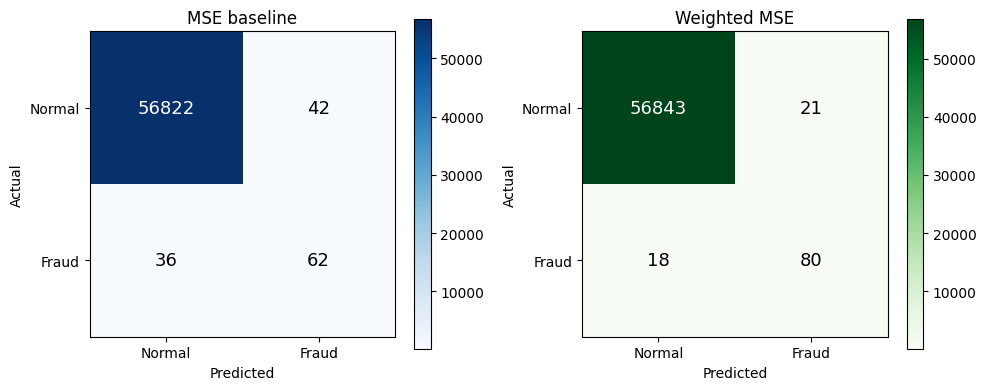

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, y_pred, title, cmap in zip(
        axes, [y_pred_base, y_pred_weighted],
        ['MSE baseline', 'Weighted MSE'], ['Blues', 'Greens']):
    cm = confusion_matrix(y_test, y_pred)
    im = ax.imshow(cm, cmap=cmap)
    plt.colorbar(im, ax=ax)
    ax.set_xticks([0,1]); ax.set_xticklabels(['Normal', 'Fraud'])
    ax.set_yticks([0,1]); ax.set_yticklabels(['Normal', 'Fraud'])
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual'); ax.set_title(title)
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm[i,j]), ha='center', va='center',
                    color='white' if cm[i,j] > cm.max()/2 else 'black', fontsize=13)
plt.tight_layout(); plt.show()

## Explainability

### Per-feature Reconstruction Error

Per-feature reconstruction error on the test set, comparing normal and fraudulent transactions.  
Features with a much higher error on frauds are the ones the autoencoder struggles with most — they carry the strongest anomaly signal.

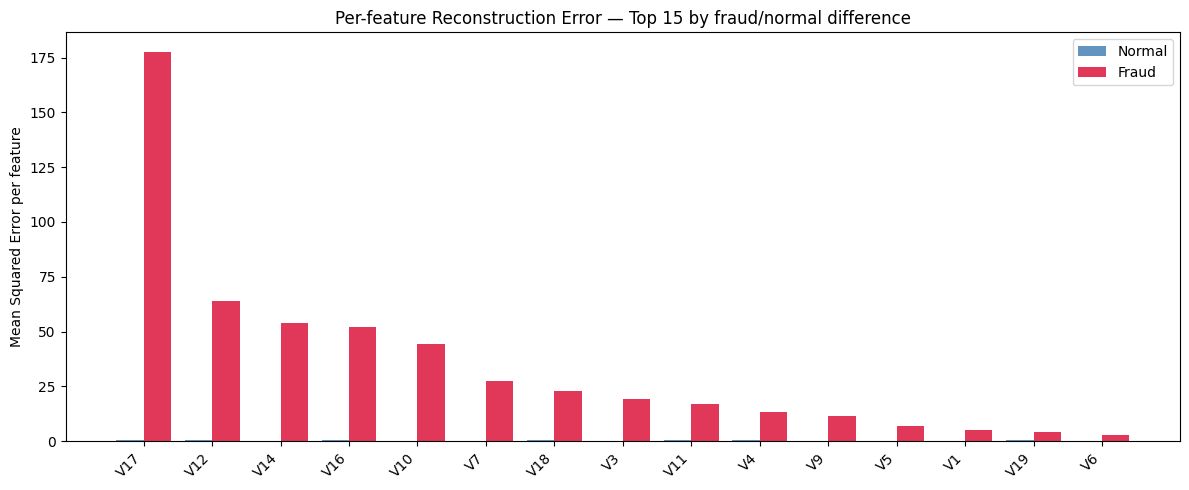

In [21]:
per_feat_test = (X_test - test_rec) ** 2
err_n_t = per_feat_test[y_test == 0].mean(axis=0)
err_f_t = per_feat_test[y_test == 1].mean(axis=0)

order = np.argsort(err_f_t - err_n_t)[::-1][:15]
x_pos = np.arange(len(order))

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x_pos - 0.2, err_n_t[order], width=0.4, label='Normal', color='steelblue', alpha=0.85)
ax.bar(x_pos + 0.2, err_f_t[order], width=0.4, label='Fraud',  color='crimson',   alpha=0.85)
ax.set_xticks(x_pos)
ax.set_xticklabels([feature_names[i] for i in order], rotation=45, ha='right')
ax.set_ylabel('Mean Squared Error per feature')
ax.set_title('Per-feature Reconstruction Error — Top 15 by fraud/normal difference')
ax.legend(); plt.tight_layout(); plt.show()

### Permutation Feature Importance

For each feature: randomly shuffle its values in the test set and measure the drop in Average Precision using the Weighted MSE score.  
A larger drop means the feature is more important for fraud detection.

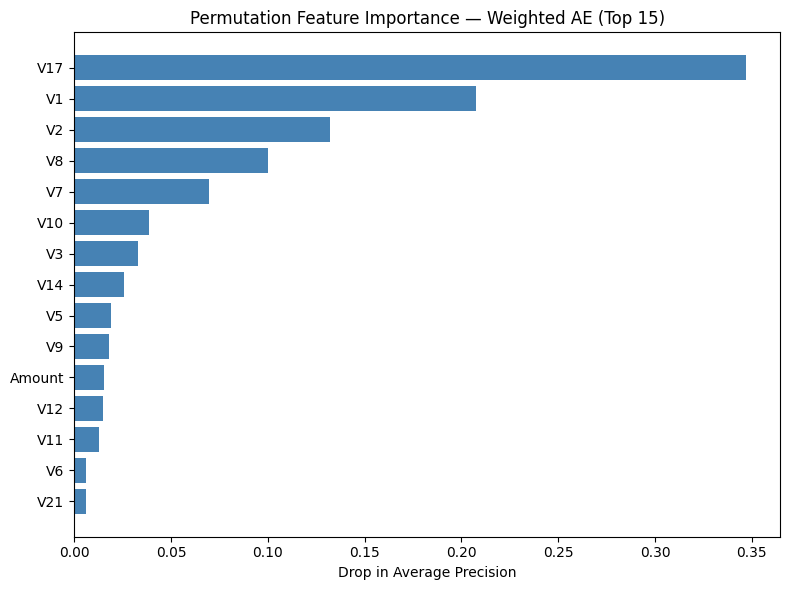

In [22]:
baseline_ap = average_precision_score(y_test, w_err_test)
perm_imp = []

for i in range(X_test.shape[1]):
    X_perm = X_test.copy()
    X_perm[:, i] = np.random.permutation(X_perm[:, i])
    with torch.no_grad():
        rec_p = model(torch.FloatTensor(X_perm)).numpy()
    score_p = np.average((X_perm - rec_p) ** 2, axis=1, weights=weights)
    perm_imp.append(baseline_ap - average_precision_score(y_test, score_p))

perm_imp = np.array(perm_imp)
order_p  = np.argsort(perm_imp)[::-1][:15]

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(range(15), perm_imp[order_p][::-1], color='steelblue')
ax.set_yticks(range(15))
ax.set_yticklabels([feature_names[i] for i in order_p][::-1])
ax.set_xlabel('Drop in Average Precision')
ax.set_title('Permutation Feature Importance — Weighted AE (Top 15)')
plt.tight_layout(); plt.show()